In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.eda_utils import *

ModuleNotFoundError: No module named 'src'

In [2]:
import sys
sys.path.append("../")

from src.data_loader import load_data
from src.eda_utils import *

In [3]:
df = load_data("../data/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [4]:
df.shape

(10000, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

In [6]:
summarize(df)

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


In [7]:
datatype_info(df)

CustomerID                 str
Age                      int64
Gender                     str
Province                   str
VehicleType                str
AnnualIncome             int64
RiskScore                int64
AnnualPremium            int64
Deductible               int64
NCD                      int64
PastClaims               int64
Claimed                   bool
ClaimAmount            float64
TotalPremium             int64
TotalClaims            float64
CoverType                  str
AutoMake                   str
VehicleModel               str
CustomValueEstimate      int64
ZipCode                  int64
TransactionDate            str
dtype: object

In [8]:
missing = check_missing(df)
missing[missing >0]

Series([], dtype: int64)

Missing values were identified in several columns.
Columns with small proportions of missing values will be imputed.
Columns with large proportions may be removed after further analysis.

In [9]:
loss_ratio(df)
df["LossRatio"] = (
    df["TotalClaims"]
    /
    df["TotalPremium"]
)

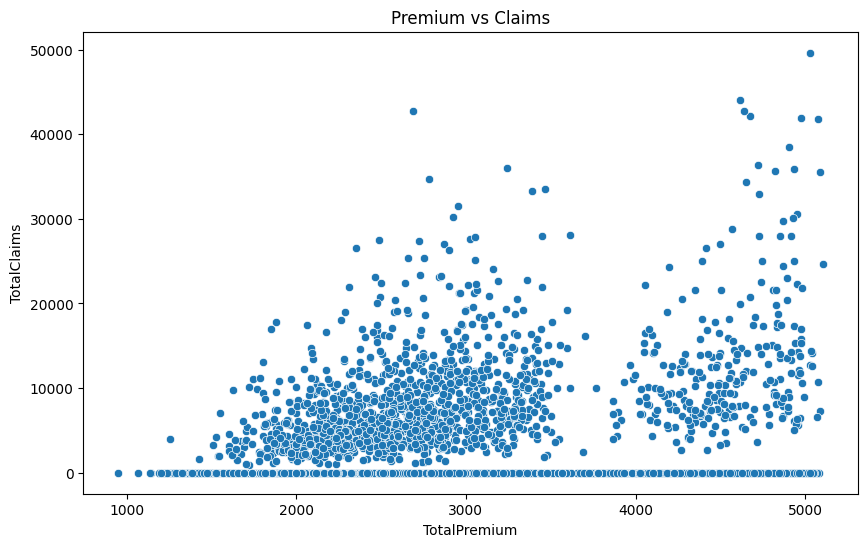

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims"
)

plt.title(
    "Premium vs Claims"
)

plt.show()

In [ ]:
missing = check_missing(df)

missing[missing > 0].sort_values(
    ascending=False
)

## Data Quality Assessment

The dataset was examined for missing values across all features.
Columns with relatively few missing values may be imputed, while
columns with substantial missingness may require removal or more
advanced handling strategies.

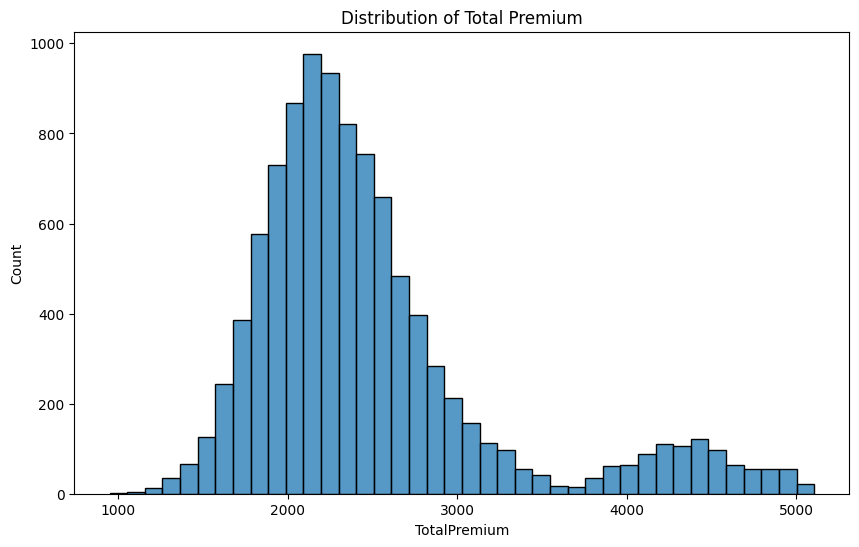

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["TotalPremium"],
    bins=40
)

plt.title(
    "Distribution of Total Premium"
)

plt.show()

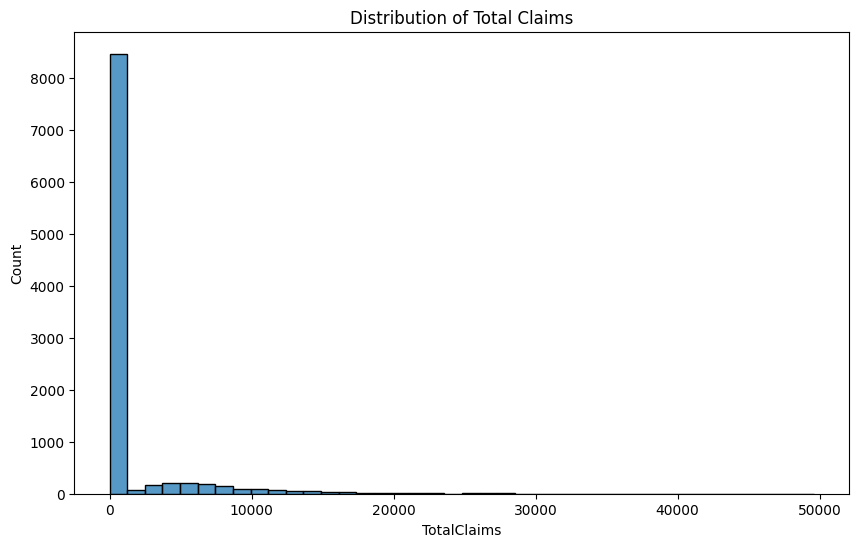

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["TotalClaims"],
    bins=40
)

plt.title(
    "Distribution of Total Claims"
)

plt.show()

Observation:

The financial variables show the distribution of premiums and claims
across policies. Visual inspection helps identify skewness and unusual
patterns requiring further investigation.

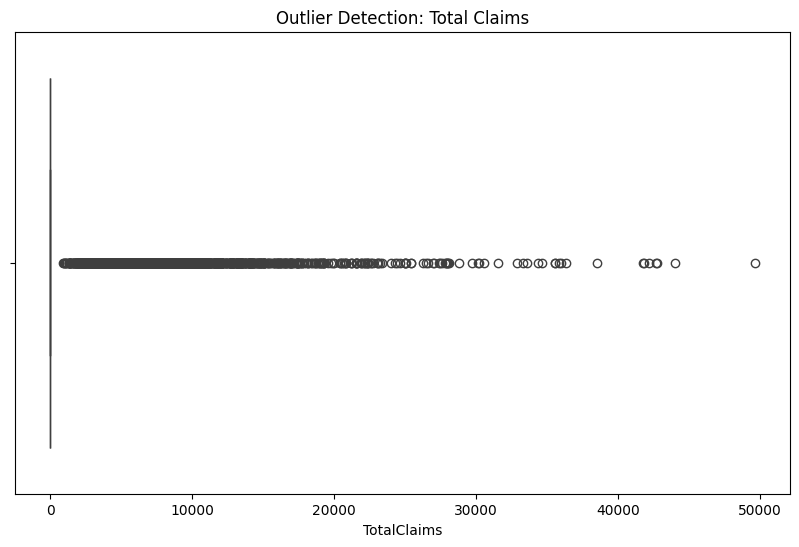

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["TotalClaims"]
)

plt.title(
    "Outlier Detection: Total Claims"
)

plt.show()

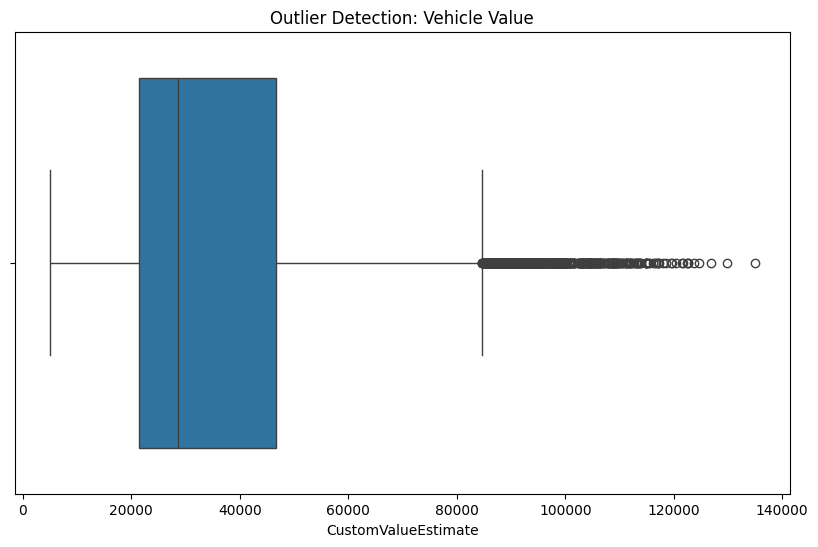

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["CustomValueEstimate"]
)

plt.title(
    "Outlier Detection: Vehicle Value"
)

plt.show()

Observation:

Box plots indicate whether extreme values exist within claims and
vehicle value estimates. Large outliers could disproportionately
influence statistical analysis and predictive modeling.

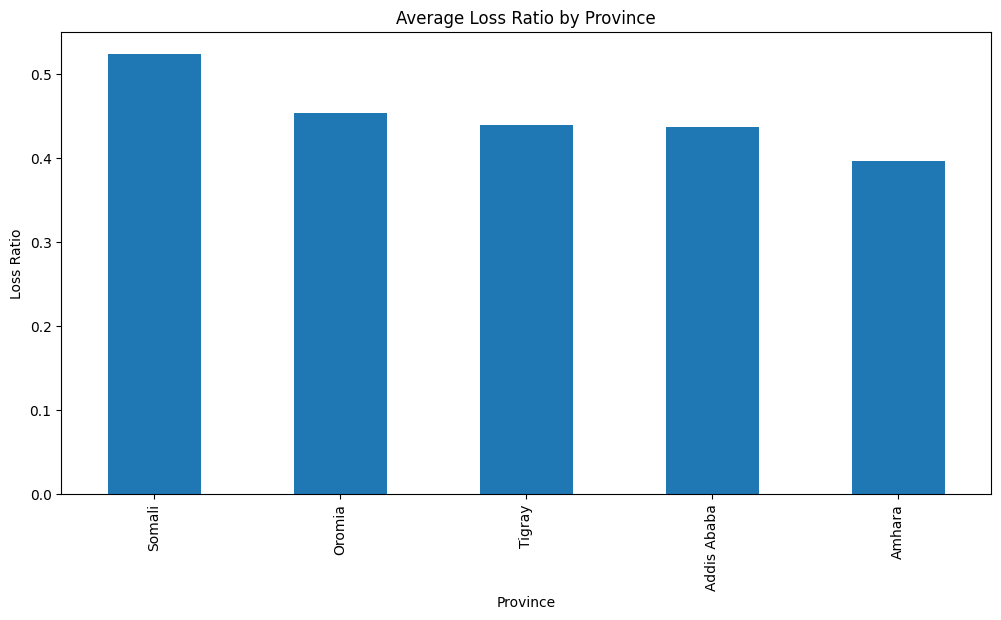

In [26]:
province_risk = df.groupby(
    "Province"
)["LossRatio"].mean()

province_risk.sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Average Loss Ratio by Province"
)

plt.ylabel(
    "Loss Ratio"
)

plt.show()

Observation:

The chart compares average portfolio risk across provinces and may
highlight geographic areas associated with higher insurance risk.

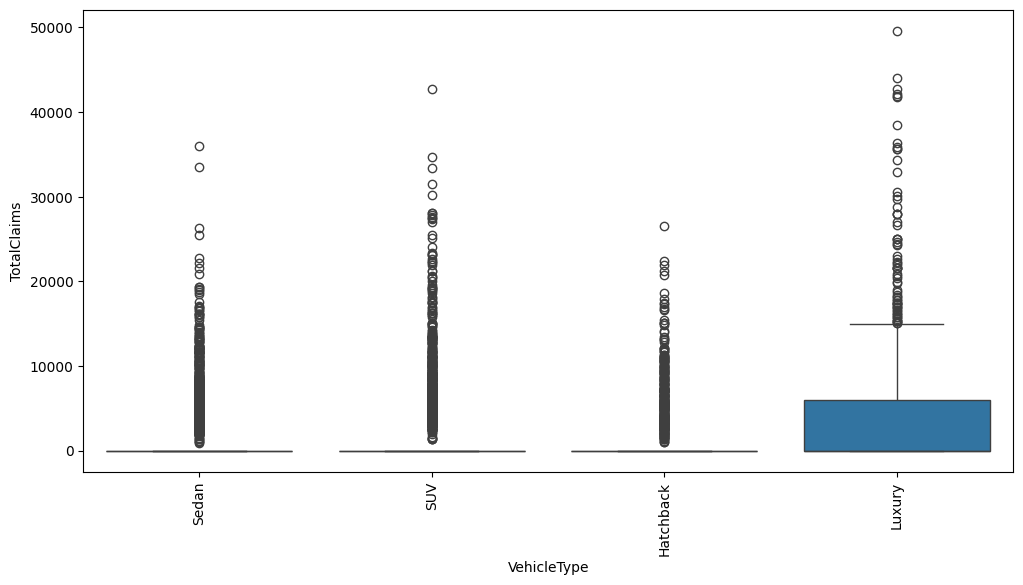

In [27]:
plt.figure(
    figsize=(12,6)
)

sns.boxplot(
    data=df,
    x="VehicleType",
    y="TotalClaims"
)

plt.xticks(
    rotation=90
)

plt.show()

In [28]:
monthly = df.groupby(
    "TransactionMonth"
)["TotalClaims"].mean()

plt.figure(
    figsize=(12,6)
)

monthly.plot()

plt.title(
    "Claims Trend Over Time"
)

plt.ylabel(
    "Average Claims"
)

plt.show()

KeyError: 'TransactionMonth'

In [29]:
df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'Province',
 'VehicleType',
 'AnnualIncome',
 'RiskScore',
 'AnnualPremium',
 'Deductible',
 'NCD',
 'PastClaims',
 'Claimed',
 'ClaimAmount',
 'TotalPremium',
 'TotalClaims',
 'CoverType',
 'AutoMake',
 'VehicleModel',
 'CustomValueEstimate',
 'ZipCode',
 'TransactionDate',
 'LossRatio']

In [31]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["TransactionMonth"] = df["TransactionDate"].dt.to_period("M")

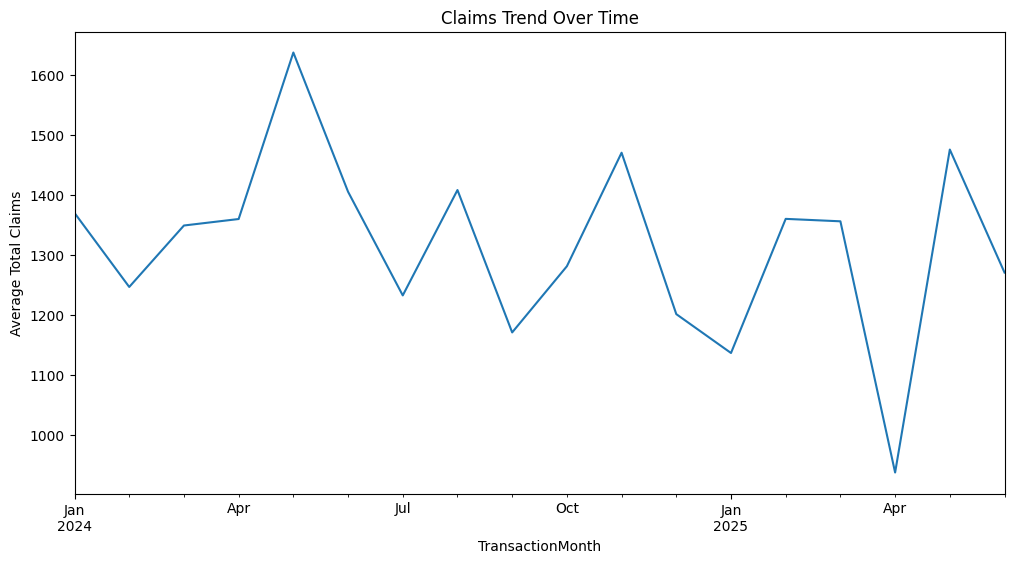

In [32]:
monthly = df.groupby(
    "TransactionMonth"
)["TotalClaims"].mean()

monthly.plot(
    figsize=(12,6),
    title="Claims Trend Over Time"
)

plt.ylabel("Average Total Claims")
plt.show()

In [33]:
df[["LossRatio", "TotalClaims", "TotalPremium"]].head()


,LossRatio,TotalClaims,TotalPremium
0,0.000000,0.0,2346
1,4.234362,9883.0,2334
2,0.000000,0.0,1697
3,5.119831,12134.0,2370
4,0.000000,0.0,2582


In [34]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

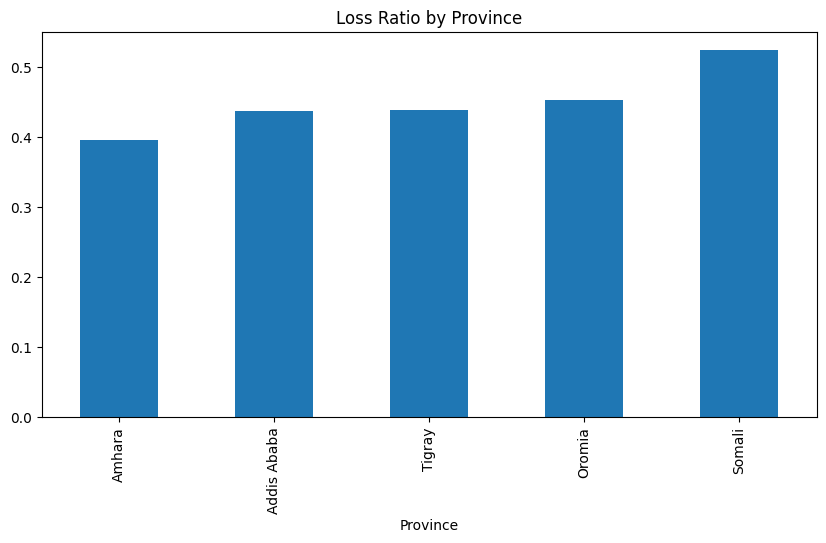

In [35]:
df.groupby("Province")["LossRatio"].mean().sort_values().plot(
    kind="bar",
    figsize=(10,5),
    title="Loss Ratio by Province"
)
plt.show()

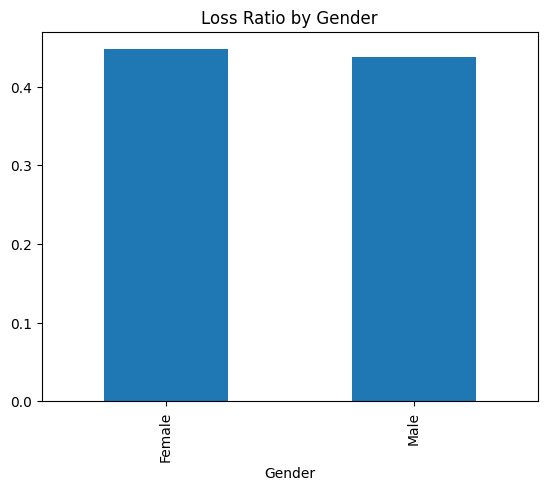

In [36]:
df.groupby("Gender")["LossRatio"].mean().plot(
    kind="bar",
    title="Loss Ratio by Gender"
)
plt.show()

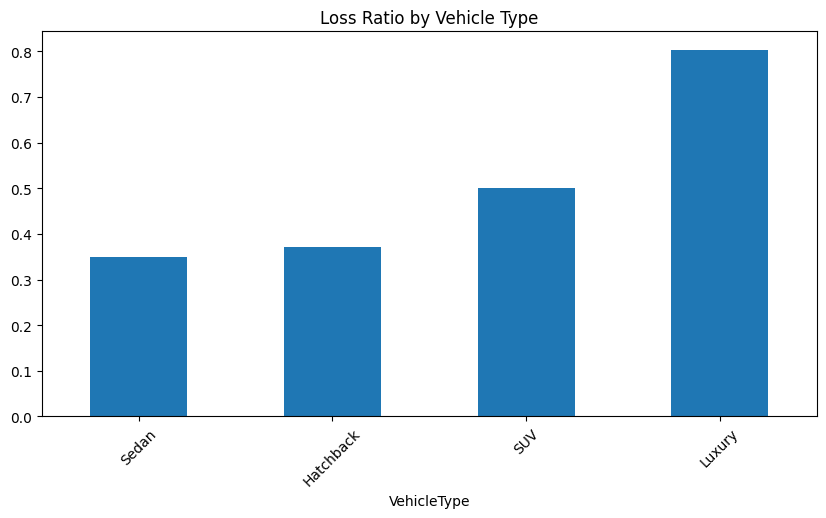

In [37]:
df.groupby("VehicleType")["LossRatio"].mean().sort_values().plot(
    kind="bar",
    figsize=(10,5),
    title="Loss Ratio by Vehicle Type"
)
plt.xticks(rotation=45)
plt.show()

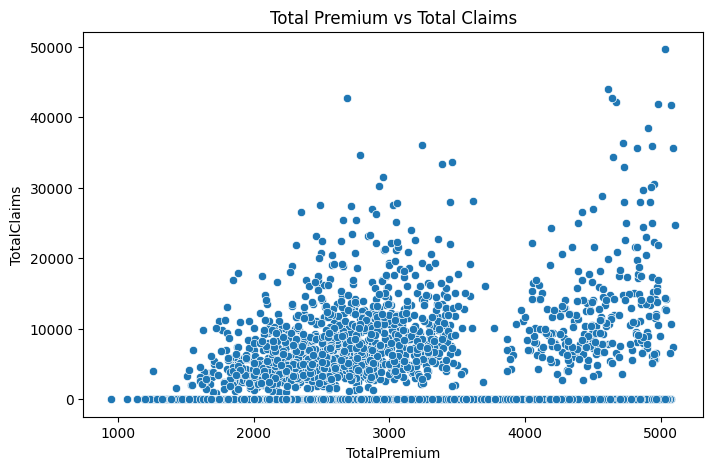

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims"
)

plt.title("Total Premium vs Total Claims")
plt.show()

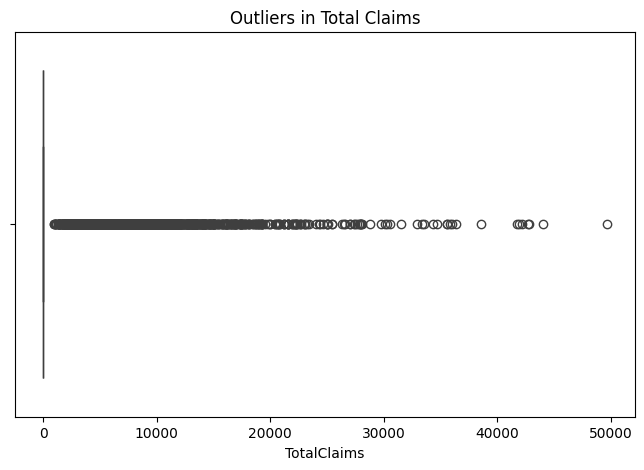

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalClaims"])
plt.title("Outliers in Total Claims")
plt.show()

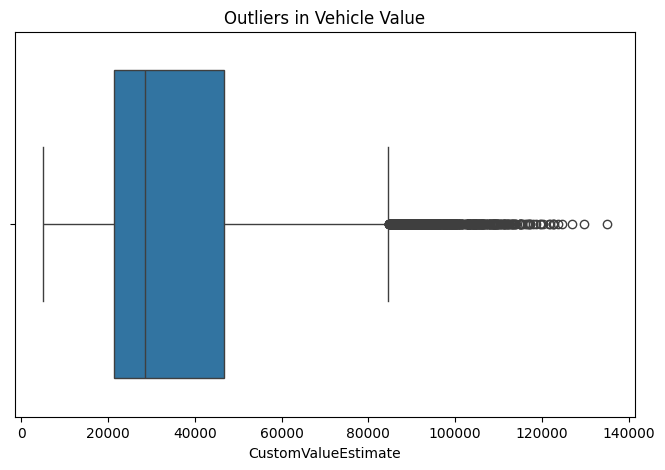

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["CustomValueEstimate"])
plt.title("Outliers in Vehicle Value")
plt.show()

<Axes: xlabel='TransactionMonth'>

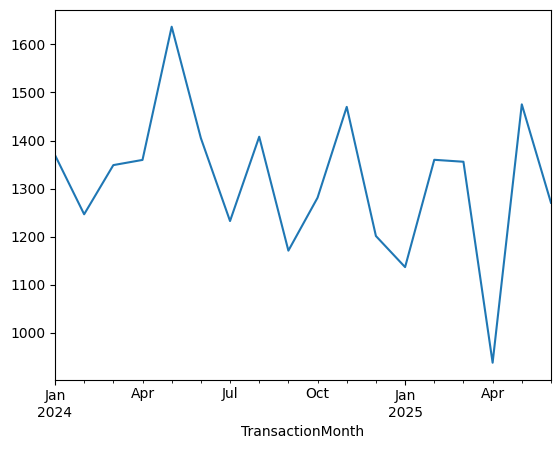

In [41]:
df.groupby("TransactionMonth")["TotalClaims"].mean().plot()

In [42]:
df.to_csv("data/insurance_data_clean.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data'